In [ ]:
import os
from openai import OpenAI
import IPython.display as ipd
from PIL import Image
import base64
from io import BytesIO


In [10]:
%%bash

# Ensure any previous ollama instances are stopped
killall ollama || true

# Fetch and install the latest release of ollama.
curl -fsSL https://ollama.com/install.sh | sh

# Start and ollama server locally on the backend.
nohup ollama serve > /tmp/ollama_serve_stdout.log 2>/tmp/ollama_serve_stderr.log &

ollama: no process found
>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


In [11]:
!ollama pull gemma3:4b

from openai import OpenAI
client = OpenAI(base_url="http://localhost:11434/v1", api_key="ollama")

In [12]:
# Verify the installed Ollama models
!ollama list

NAME            ID              SIZE      MODIFIED               
gemma3:4b       a2af6cc3eb7f    3.3 GB    Less than a second ago    
llava:latest    8dd30f6b0cb1    4.7 GB    About an hour ago         


In [13]:
import time

# Add a small delay to ensure Ollama server has loaded the model
time.sleep(5)

response = client.chat.completions.create(
    model="gemma3:4b",
    messages=[
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": "What is the capital of France?"}
    ]
)
print(response.choices[0].message.content)

The capital of France is **Paris**. 

It’s a beautiful and historic city! 😊 

Do you want to know anything else about Paris or France?


In [14]:
#1. Check if Ollama processes are running
print("Checking for running Ollama processes:")
os.system("ps aux | grep -E \"ollama\" | grep -v grep || true")

#2. Kill any existing Ollama processes to ensure a clean start
print("\nKilling any existing Ollama processes...")
os.system("pkill -9 ollama || true")

#3. Restart the Ollama server in the background
print("\nStarting Ollama server...")
os.system("nohup ollama serve > /tmp/ollama_serve_stdout.log 2>/tmp/ollama_serve_stderr.log &")

#4. Give the server a moment to start up
print("\nWaiting 5 seconds for Ollama server to start...")
os.system("sleep 5")

#5. Verify Ollama API is accessible and list models
print ("\nIf a JSON string shows below, the Ollama server is working:")
os.system("curl -s http://localhost:11434/v1/models")

#6. Check if gemma3:4b is listed
print ("\nMake sure that gemma3:4b is still listed. If not, you will need to re-pull it:")
os.system("ollama list")

Checking for running Ollama processes:

Killing any existing Ollama processes...

Starting Ollama server...

Waiting 5 seconds for Ollama server to start...

If a JSON string shows below, the Ollama server is working:

Make sure that gemma3:4b is still listed. If not, you will need to re-pull it:


0

In [16]:
# Use the same client setup as before
client = OpenAI(base_url="http://localhost:11434/v1", api_key="ollama")

def display_image(image_path):
    """Display image in Jupyter notebook environment"""
    try:
        image = Image.open(image_path).convert("RGB")
        display(image)  # This works in Jupyter notebooks
        return image
    except Exception as e:
        print(f"Error displaying image: {e}")
        return None

def encode_image_to_base64(image_path):
    """Convert image to base64 string for API"""
    try:
        with open(image_path, "rb") as image_file:
            return base64.b64encode(image_file.read()).decode('utf-8')
    except Exception as e:
        print(f"Error encoding image: {e}")
        return None

def ask_about_image(image_path, question, model="gemma3:4b"):
    """Ask a question about an image using Ollama via OpenAI-compatible API"""

    # First, make sure the model is available
    print(f"Using model: {model}")

    # Encode the image
    base64_image = encode_image_to_base64(image_path)
    if not base64_image:
        return "Failed to encode image"

    try:
        response = client.chat.completions.create(
            model=model,
            messages=[
                {
                    "role": "user",
                    "content": [
                        {
                            "type": "text",
                            "text": question
                        },
                        {
                            "type": "image_url",
                            "image_url": {
                                "url": f"data:images/jpg;base64,{base64_image}"
                            }
                        }
                    ]
                }
            ],
            max_tokens=512,
            temperature=0.5
        )
        return response.choices[0].message.content
    except Exception as e:
        print(f"API Error: {e}")
        return f"Error: {e}"

# First, let's check what models are available
print("\nChecking available models...")
os.system("ollama list")

# Try to pull llava model if not available
print("\nEnsuring llava model is available...")
os.system("ollama pull llava")


Checking available models...

Ensuring llava model is available...


0

In [17]:
paths = "/content/ocr-receipts-text-detection/images"

# Test questions
questions = [
    "Extract all the text from the image.",
    "Check that the receipt is accurate."
]

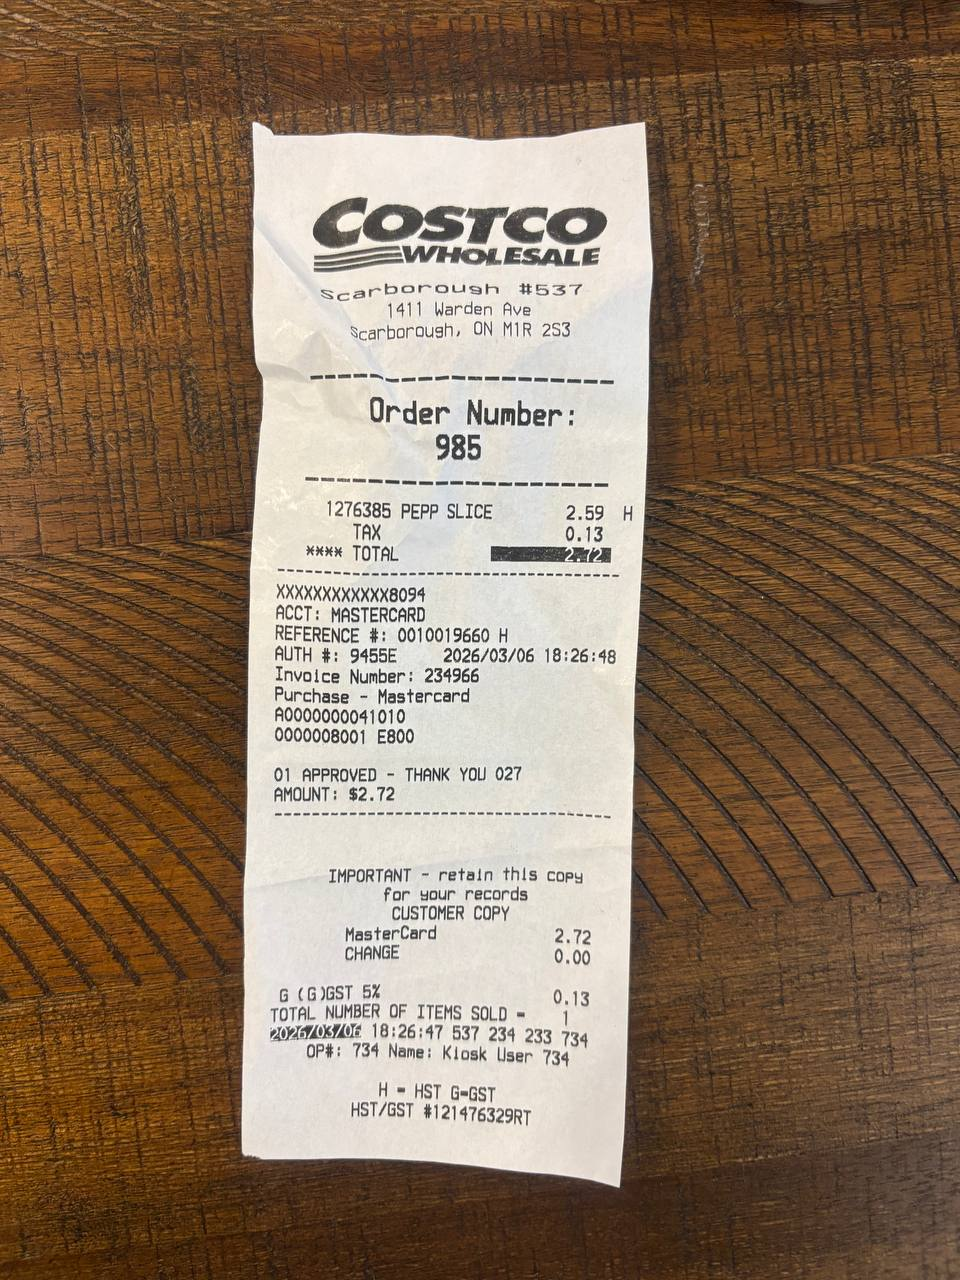


Question 1: Extract all the text from the image.
Using model: gemma3:4b
API Error: Error code: 400 - {'error': {'message': 'invalid image input', 'type': 'invalid_request_error', 'param': None, 'code': None}}
Answer: Error: Error code: 400 - {'error': {'message': 'invalid image input', 'type': 'invalid_request_error', 'param': None, 'code': None}}

Question 2: Check that the receipt is accurate.
Using model: gemma3:4b
API Error: Error code: 400 - {'error': {'message': 'invalid image input', 'type': 'invalid_request_error', 'param': None, 'code': None}}
Answer: Error: Error code: 400 - {'error': {'message': 'invalid image input', 'type': 'invalid_request_error', 'param': None, 'code': None}}


In [18]:
image_path_to_check = "/content/ocr-receipts-text-detection/images/test.jpeg"

print()
image = display_image(image_path_to_check)
for i, question in enumerate(questions, 1):
    print(f"\nQuestion {i}: {question}")
    answer = ask_about_image(image_path_to_check, question, "gemma3:4b")
    print(f"Answer: {answer}")